**Install + imports**

In [1]:
!pip -q install segmentation-models-pytorch==0.3.3 albumentations==1.4.7 opencv-python==4.10.0.84 rapidfuzz timm

import os, json, re
import numpy as np
import cv2
import pandas as pd
from rapidfuzz import process, fuzz

import torch
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 27.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 71.9 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Device: cpu


**Set paths**

In [2]:
# ====== INPUT IMAGE ======
IMAGE_PATH = "/kaggle/input/test-images/sample.jpg" 
#IMAGE_PATH = "/kaggle/input/test-images/sample1.jpg"
#IMAGE_PATH = "/kaggle/input/test-images/sample2.jpg"
#IMAGE_PATH = "/kaggle/input/test-images/sample3.jpg"
#IMAGE_PATH = "/kaggle/input/test-images/sample4.jpg"
#IMAGE_PATH = "/kaggle/input/test-images/sample5.jpg"
#IMAGE_PATH = "/kaggle/input/test-images/sample6.jpg"

# ====== PHASE 1 (OPTIONAL) ======
PHASE1_WEIGHTS = "/kaggle/input/food101-model/pytorch/default/1/best_food101_effnetb2 .pth" 

# ====== PHASE 2 SEGMENTATION CHECKPOINT ======
PHASE2_CKPT = "/kaggle/input/foodseg-model/pytorch/default/1/best_deeplabv3plus_mnv2_foodseg103.pth"  

# ====== FOODSEG CLASS NAMES FILE ======
CLASS_NAMES_TXT = "/kaggle/input/foodseg103-class-names/category_id.txt"  

# ====== USDA TRAIN CSV ======
USDA_TRAIN_CSV = "/kaggle/input/usda-national-nutrient-database/train.csv" 

OUT_DIR = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)

print("IMAGE exists:", os.path.exists(IMAGE_PATH))
print("CKPT exists:", os.path.exists(PHASE2_CKPT))
print("class_names exists:", os.path.exists(CLASS_NAMES_TXT))
print("USDA exists:", os.path.exists(USDA_TRAIN_CSV))


IMAGE exists: True
CKPT exists: True
class_names exists: True
USDA exists: True


**Phase 1 Classification**

In [3]:
def phase1_load_model(weights_path: str):
    model = timm.create_model("tf_efficientnet_b2", pretrained=False, num_classes=101)
    if os.path.exists(weights_path):
        state = torch.load(weights_path, map_location=device)
        model.load_state_dict(state)
        model.to(device).eval()
        return model
    return None

def phase1_preprocess(img_rgb):
    img = cv2.resize(img_rgb, (260, 260))
    x = img.astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    x = (x - mean) / std
    x = np.transpose(x, (2,0,1))
    return torch.tensor(x).unsqueeze(0)

def phase1_predict_topk(model, image_path, topk=5):
    if model is None:
        return {"status": "skipped", "reason": "Phase 1 weights not found", "topk": []}

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    x = phase1_preprocess(img).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

    top_idx = probs.argsort()[::-1][:topk]
    return {
        "status":"ok",
        "topk":[{"class_index": int(i), "prob": float(probs[i])} for i in top_idx]
    }

phase1_model = phase1_load_model(PHASE1_WEIGHTS)
phase1_out = phase1_predict_topk(phase1_model, IMAGE_PATH)
print("Phase 1:", phase1_out["status"], phase1_out["topk"])


Phase 1: ok [{'class_index': 18, 'prob': 0.2760002017021179}, {'class_index': 37, 'prob': 0.25481945276260376}, {'class_index': 50, 'prob': 0.08122720569372177}, {'class_index': 47, 'prob': 0.07715108245611191}, {'class_index': 93, 'prob': 0.04837113991379738}]


In [4]:
# Load Food101 class names
with open("/kaggle/input/food101/classes.txt", "r") as f:
    food101_classes = [l.strip() for l in f.readlines()]

for p in phase1_out["topk"]:
    idx = p["class_index"]
    print(food101_classes[idx], "→", round(p["prob"]*100, 1), "%")


chicken_curry → 27.6 %
filet_mignon → 25.5 %
grilled_salmon → 8.1 %
gnocchi → 7.7 %
steak → 4.8 %


**Phase 2 Segmentation: load class names + model + inference**

In [5]:
def load_class_names(path):
    names = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            parts = s.replace(",", " ").split()
            if len(parts) >= 2 and parts[0].isdigit():
                names.append(" ".join(parts[1:]))
            else:
                names.append(s)
    return names

val_tfms = A.Compose([
    A.LongestMaxSize(max_size=512),
    A.PadIfNeeded(min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

def build_seg_model(num_classes):
    return smp.DeepLabV3Plus(
        encoder_name="mobilenet_v2",
        encoder_weights="imagenet",
        in_channels=3,
        classes=num_classes
    )

def load_seg_checkpoint(model, ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)

    # handle checkpoint format
    if isinstance(ckpt, dict):
        if "model" in ckpt:
            state = ckpt["model"]
        elif "state_dict" in ckpt:
            state = ckpt["state_dict"]
        elif "model_state" in ckpt:          
            state = ckpt["model_state"]
        else:
            # fallback: if dict is already a state_dict
            state = ckpt
    else:
        state = ckpt

    model.load_state_dict(state, strict=True)
    model.to(device).eval()
    return model


def predict_probs_and_mask(model, image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    out = val_tfms(image=img, mask=np.zeros((img.shape[0], img.shape[1]), dtype=np.int64))
    x = out["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()  # [C,H,W]
        pred = np.argmax(probs, axis=0).astype(np.int64)               # [H,W]
    return img, pred, probs

def get_detected_foods(pred_mask, probs, class_names, min_area_frac=0.01):
    H, W = pred_mask.shape
    total = H * W
    out = []
    for cid in range(probs.shape[0]):
        label = class_names[cid] if cid < len(class_names) else f"class_{cid}"
        if label.lower() == "background":
            continue
        pix = (pred_mask == cid)
        count = int(pix.sum())
        area_frac = count / total
        if area_frac < min_area_frac:
            continue
        conf = float(probs[cid][pix].mean()) if count else 0.0
        out.append({
            "class_id": int(cid),
            "label": label,
            "confidence": conf,
            "area_fraction": float(area_frac),
            "pixel_count": count
        })
    out.sort(key=lambda x: x["area_fraction"], reverse=True)
    return out

class_names = load_class_names(CLASS_NAMES_TXT)
seg_model = build_seg_model(len(class_names))
seg_model = load_seg_checkpoint(seg_model, PHASE2_CKPT)

img_rgb, pred_mask, probs = predict_probs_and_mask(seg_model, IMAGE_PATH)
detected_foods = get_detected_foods(pred_mask, probs, class_names)

# save phase 2 output
P2_PATH = os.path.join(OUT_DIR, "detected_foods.json")
with open(P2_PATH, "w") as f:
    json.dump(detected_foods, f, indent=2)

print("✅ Saved:", P2_PATH)
print("Detected foods:", [d["label"] for d in detected_foods])


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 143MB/s]


✅ Saved: /kaggle/working/detected_foods.json
Detected foods: ['carrot', 'rice', 'French beans', 'shrimp', 'fish']


**Phase 3 Portion estimation**

In [6]:
def estimate_portions_area_based(foods, conf_thresh=0.30):
    portions = []
    for f in foods:
        if float(f["confidence"]) < conf_thresh:
            continue
        portions.append({
            "label": f["label"],
            "confidence": float(f["confidence"]),
            "area_fraction": float(f["area_fraction"]),
            "pixel_count": int(f["pixel_count"]),
            "portion_score": float(f["area_fraction"])
        })
    portions.sort(key=lambda x: x["portion_score"], reverse=True)
    return portions

GRAMS_PER_1PCT = {
    "rice": 12,
    "bean": 8,
    "beans": 8,
    "carrot": 6,
    "shrimp": 18,
    "prawn": 18,
    "default": 10
}

def estimate_grams(label, area_fraction):
    lab = label.lower()
    g_per_pct = GRAMS_PER_1PCT["default"]
    for k, v in GRAMS_PER_1PCT.items():
        if k != "default" and k in lab:
            g_per_pct = v
            break
    return float(g_per_pct * (area_fraction * 100.0))

portions = estimate_portions_area_based(detected_foods)
portions_grams = [{**p, "estimated_grams": estimate_grams(p["label"], p["area_fraction"])} for p in portions]

P3_PATH = os.path.join(OUT_DIR, "phase3_portions.json")
with open(P3_PATH, "w") as f:
    json.dump({"portions": portions_grams}, f, indent=2)

print("✅ Saved:", P3_PATH)
for p in portions_grams:
    print(p["label"], "grams≈", round(p["estimated_grams"], 1))


✅ Saved: /kaggle/working/phase3_portions.json
carrot grams≈ 260.0
rice grams≈ 144.4
French beans grams≈ 56.9
shrimp grams≈ 74.1
fish grams≈ 11.4


**Phase 4 Nutrition mapping (USDA)**

In [7]:
usda_df = pd.read_csv(USDA_TRAIN_CSV)
usda_df["desc_norm"] = usda_df["Descrip"].astype(str).str.lower()

def normalize_text(s):
    s = str(s).lower().strip()
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def match_usda_grouped(label, min_score=60):
    lab = normalize_text(label)

    if "rice" in lab:
        df_sub = usda_df[usda_df["FoodGroup"].str.contains("Cereal Grains and Pasta", case=False, na=False)]
        query = "rice white cooked"
        df_sub = df_sub[df_sub["desc_norm"].str.contains("rice", na=False)]
    elif "shrimp" in lab or "prawn" in lab:
        df_sub = usda_df[usda_df["FoodGroup"].str.contains("Finfish and Shellfish Products", case=False, na=False)]
        query = "shrimp"
        df_sub = df_sub[df_sub["desc_norm"].str.contains("shrimp", na=False)]
    elif "bean" in lab:
        df_sub = usda_df[usda_df["FoodGroup"].str.contains("Vegetable", case=False, na=False)]
        query = "beans snap green"
    elif "carrot" in lab:
        df_sub = usda_df[usda_df["FoodGroup"].str.contains("Vegetable", case=False, na=False)]
        query = "carrots raw"
    else:
        df_sub = usda_df
        query = lab

    if len(df_sub) == 0:
        df_sub = usda_df

    df_sub = df_sub.copy()
    df_sub["norm"] = df_sub["Descrip"].astype(str).map(normalize_text)
    choices = df_sub["norm"].tolist()

    m = process.extractOne(query, choices, scorer=fuzz.WRatio)
    if m is None:
        return None, 0.0
    _, score, idx = m
    if score < min_score:
        return None, float(score)

    row = df_sub.iloc[idx]
    per100 = {
        "matched_name": row["Descrip"],
        "food_group": row["FoodGroup"],
        "kcal": float(row["Energy_kcal"]),
        "protein_g": float(row["Protein_g"]),
        "fat_g": float(row["Fat_g"]),
        "carbs_g": float(row["Carb_g"]),
        "sugar_g": float(row["Sugar_g"]),
        "fiber_g": float(row["Fiber_g"]),
    }
    return per100, float(score)

def scale(per100, grams):
    factor = grams / 100.0
    return {k: per100[k]*factor for k in ["kcal","protein_g","fat_g","carbs_g","sugar_g","fiber_g"]}

items = []
totals = {"kcal":0,"protein_g":0,"fat_g":0,"carbs_g":0,"sugar_g":0,"fiber_g":0}

for p in portions_grams:
    grams = float(p["estimated_grams"])
    per100, score = match_usda_grouped(p["label"])
    if per100 is None:
        items.append({"label": p["label"], "grams": grams, "match_status":"no_match", "match_score": score})
        continue
    nut = scale(per100, grams)
    items.append({"label": p["label"], "grams": grams, "usda_match": per100["matched_name"], "match_score": score, "nutrition": nut})
    for k in totals:
        totals[k] += nut[k]

phase4 = {"items": items, "totals": totals}

P4_PATH = os.path.join(OUT_DIR, "phase4_nutrition.json")
with open(P4_PATH, "w") as f:
    json.dump(phase4, f, indent=2)

print("✅ Saved:", P4_PATH)
print("Totals:", totals)


✅ Saved: /kaggle/working/phase4_nutrition.json
Totals: {'kcal': 333.7178726196289, 'protein_g': 23.045869750976564, 'fat_g': 1.939281234741211, 'carbs_g': 55.831571350097654, 'sugar_g': 14.300881042480468, 'fiber_g': 10.518495941162108}


**Phase 5 Rules + Meal rating + Food-level recommendations**

In [8]:
def apply_phase5(totals, items):
    kcal = float(totals.get("kcal",0))
    carbs = float(totals.get("carbs_g",0))
    fiber = float(totals.get("fiber_g",0))
    sugar = float(totals.get("sugar_g",0))
    protein = float(totals.get("protein_g",0))
    fat = float(totals.get("fat_g",0))
    net_carbs = max(carbs - fiber, 0)

    RULES = {
        "net_carbs_high": 60,
        "net_carbs_very_high": 80,
        "sugar_high": 25,
        "fiber_good": 8,
        "fiber_chol_good": 10,
        "fat_high": 25,
        "protein_low": 20
    }

    recs = []
    scores = {"blood_sugar": 0, "cholesterol": 0}

    recs.append({"type":"info","message": f"Meal summary: {kcal:.0f} kcal | Net carbs: {net_carbs:.1f} g | Fiber: {fiber:.1f} g | Fat: {fat:.1f} g"})
    if net_carbs >= RULES["net_carbs_very_high"]:
        recs.append({"type":"warning","message": f"Very high net carbs ({net_carbs:.1f} g)."})
        scores["blood_sugar"] += 2
    elif net_carbs >= RULES["net_carbs_high"]:
        recs.append({"type":"warning","message": f"High net carbs ({net_carbs:.1f} g)."})
        scores["blood_sugar"] += 1
    if fiber >= RULES["fiber_good"]:
        recs.append({"type":"positive","message": f"Good fiber ({fiber:.1f} g)."})
        scores["blood_sugar"] -= 1
    if fiber >= RULES["fiber_chol_good"]:
        recs.append({"type":"positive","message": f"High fiber supports cholesterol control."})
        scores["cholesterol"] -= 1
    if fat >= RULES["fat_high"]:
        recs.append({"type":"warning","message": f"High total fat ({fat:.1f} g)."})
        scores["cholesterol"] += 1

    # food-level recommendations
    food_recs = []
    for it in items:
        lab = it["label"].lower()
        if "rice" in lab:
            food_recs.append({"food": it["label"], "type":"warning", "message":"Reduce rice portion / choose brown rice."})
        if any(x in lab for x in ["bean","carrot","vegetable"]):
            food_recs.append({"food": it["label"], "type":"positive", "message":"Vegetable choice supports fiber intake."})
        if any(x in lab for x in ["shrimp","fish","chicken","egg"]):
            food_recs.append({"food": it["label"], "type":"positive", "message":"Lean protein helps balance carbs."})

    risk = scores["blood_sugar"] + scores["cholesterol"]
    if risk >= 2:
        rating = "RED (High risk)"
    elif risk >= 1:
        rating = "AMBER (Moderate risk)"
    else:
        rating = "GREEN (Low risk)"

    phase5 = {
        "meal_rating": rating,
        "scores": scores,
        "rules": RULES,
        "totals_used": {
            "kcal": kcal, "carbs_g": carbs, "fiber_g": fiber, "net_carbs_g": net_carbs,
            "sugar_g": sugar, "protein_g": protein, "fat_g": fat
        },
        "meal_level_recommendations": recs,
        "food_level_recommendations": food_recs
    }
    return phase5

phase5 = apply_phase5(totals, items)

P5_PATH = os.path.join(OUT_DIR, "phase5_recommendations.json")
with open(P5_PATH, "w") as f:
    json.dump(phase5, f, indent=2)

print("✅ Saved:", P5_PATH)
print("Meal rating:", phase5["meal_rating"])


✅ Saved: /kaggle/working/phase5_recommendations.json
Meal rating: GREEN (Low risk)


**Merge all 5 phases into one final output JSON**

In [9]:
final_output = {
    "input_image": IMAGE_PATH,
    "phase1_classification": phase1_out,
    "phase2_segmentation": {"detected_foods": detected_foods},
    "phase3_portion_estimation": {"portions": portions_grams},
    "phase4_nutrition_mapping": phase4,
    "phase5_rules_and_recommendations": phase5
}

FINAL_PATH = os.path.join(OUT_DIR, "final_pipeline_output.json")
with open(FINAL_PATH, "w") as f:
    json.dump(final_output, f, indent=2)

print("✅ FINAL saved:", FINAL_PATH)


✅ FINAL saved: /kaggle/working/final_pipeline_output.json


In [10]:
def run_full_pipeline(image_path):
    # -----------------------------
    # Phase 1: Classification
    # -----------------------------
    phase1_out = phase1_predict_topk(phase1_model, image_path)

    # -----------------------------
    # Phase 2: Segmentation
    # -----------------------------
    img, pred, probs = predict_probs_and_mask(seg_model, image_path)
    detected_foods = get_detected_foods(pred, probs, class_names)

    # -----------------------------
    # Phase 3: Portion estimation
    # -----------------------------
    portions = estimate_portions_area_based(detected_foods)
    portions_grams = [
        {**p, "estimated_grams": estimate_grams(p["label"], p["area_fraction"])}
        for p in portions
    ]

    # -----------------------------
    # Phase 4: Nutrition mapping
    # -----------------------------
    items = []
    totals = {
        "kcal": 0, "protein_g": 0, "fat_g": 0,
        "carbs_g": 0, "sugar_g": 0, "fiber_g": 0
    }

    for p in portions_grams:
        grams = float(p["estimated_grams"])
        per100, score = match_usda_grouped(p["label"])

        if per100 is None:
            items.append({
                "label": p["label"],
                "grams": grams,
                "match_status": "no_match",
                "match_score": score
            })
            continue

        nut = scale(per100, grams)

        items.append({
            "label": p["label"],
            "grams": grams,
            "usda_match": per100["matched_name"],
            "match_score": score,
            "nutrition": nut
        })

        for k in totals:
            totals[k] += nut[k]

    phase4 = {
        "items": items,
        "totals": totals
    }

    # -----------------------------
    # Phase 5: Health rules
    # -----------------------------
    phase5 = apply_phase5(totals, items)

    # -----------------------------
    # Final combined output
    # -----------------------------
    final_output = {
        "input_image": image_path,
        "phase1_classification": phase1_out,
        "phase2_segmentation": {"detected_foods": detected_foods},
        "phase3_portion_estimation": {"portions": portions_grams},
        "phase4_nutrition_mapping": phase4,
        "phase5_rules_and_recommendations": phase5
    }

    return final_output

**Unseen Data Testing**


Processing: /kaggle/input/datasets/rkr2001/unseen-images/dinner-plate.png


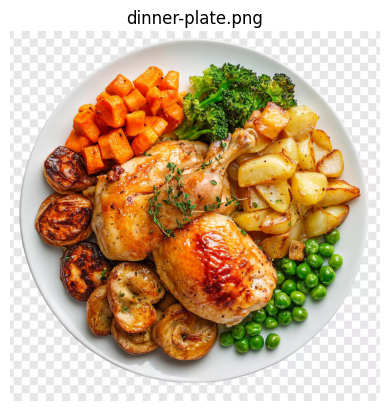

Detected foods:
- potato | conf: 0.8 | area: 0.274
- chicken duck | conf: 0.62 | area: 0.098
- carrot | conf: 0.91 | area: 0.064
- cilantro mint | conf: 0.75 | area: 0.046
- green beans | conf: 0.93 | area: 0.043

Estimated portions:
- potato | grams≈ 274.18
- chicken duck | grams≈ 97.64
- carrot | grams≈ 38.22
- cilantro mint | grams≈ 45.51
- green beans | grams≈ 34.69

Nutrition totals:
{'kcal': 653.2692947387695, 'protein_g': 13.695565643310546, 'fat_g': 18.060825271606443, 'carbs_g': 110.70357437133788, 'sugar_g': 41.70759231567383, 'fiber_g': 11.786060333251953}

Meal rating:
GREEN (Low risk)

Processing: /kaggle/input/datasets/rkr2001/unseen-images/fruit-plate.png


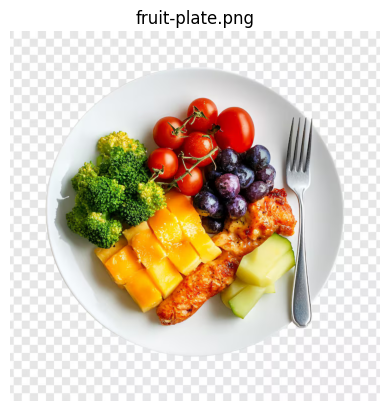

Detected foods:
- broccoli | conf: 0.91 | area: 0.053
- mango | conf: 0.68 | area: 0.052
- tomato | conf: 0.84 | area: 0.044
- pineapple | conf: 0.46 | area: 0.036
- blueberry | conf: 0.44 | area: 0.022
- fish | conf: 0.34 | area: 0.015
- avocado | conf: 0.32 | area: 0.012

Estimated portions:
- broccoli | grams≈ 53.48
- mango | grams≈ 52.2
- tomato | grams≈ 44.43
- pineapple | grams≈ 35.96
- blueberry | grams≈ 22.26
- fish | grams≈ 15.29
- avocado | grams≈ 11.7

Nutrition totals:
{'kcal': 249.31915283203125, 'protein_g': 8.436909484863282, 'fat_g': 8.20499725341797, 'carbs_g': 37.716674423217775, 'sugar_g': 8.45410614013672, 'fiber_g': 3.3545684814453125}

Meal rating:
GREEN (Low risk)

Processing: /kaggle/input/datasets/rkr2001/unseen-images/pizza.jpg


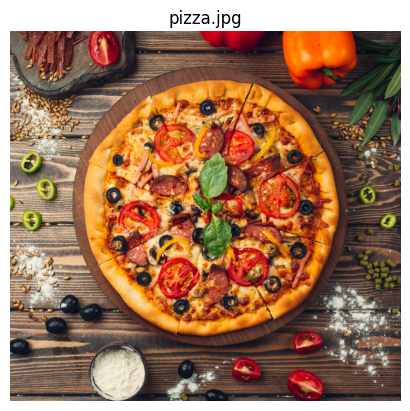

Detected foods:
- pizza | conf: 0.94 | area: 0.473
- pepper | conf: 0.67 | area: 0.018

Estimated portions:
- pizza | grams≈ 473.14
- pepper | grams≈ 17.88

Nutrition totals:
{'kcal': 1117.7647399902344, 'protein_g': 61.98052062988281, 'fat_g': 40.30947761535644, 'carbs_g': 128.88322525024415, 'sugar_g': 18.223553466796876, 'fiber_g': 23.583900451660156}

Meal rating:
AMBER (Moderate risk)

Processing: /kaggle/input/datasets/rkr2001/unseen-images/Hamburger.jpg


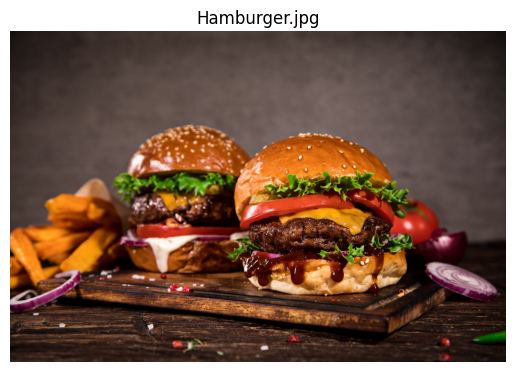

Detected foods:
- bread | conf: 0.63 | area: 0.079
- steak | conf: 0.46 | area: 0.029
- cheese butter | conf: 0.42 | area: 0.028
- french fries | conf: 0.73 | area: 0.027
- cake | conf: 0.4 | area: 0.013

Estimated portions:
- bread | grams≈ 79.48
- steak | grams≈ 29.3
- cheese butter | grams≈ 28.02
- french fries | grams≈ 27.13
- cake | grams≈ 12.81

Nutrition totals:
{'kcal': 655.091667175293, 'protein_g': 9.033771896362305, 'fat_g': 29.736245346069335, 'carbs_g': 88.65399780273437, 'sugar_g': 29.148209762573245, 'fiber_g': 3.096538543701172}

Meal rating:
RED (High risk)

Processing: /kaggle/input/datasets/rkr2001/unseen-images/ice cream.jpg


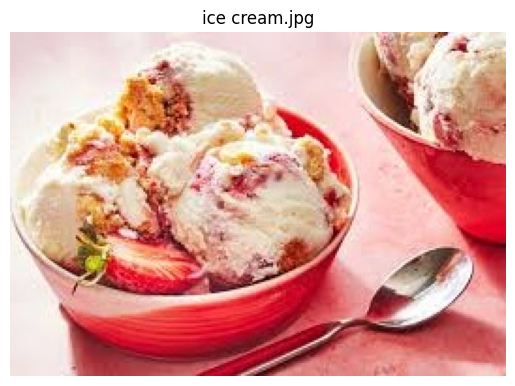

Detected foods:
- ice cream | conf: 0.82 | area: 0.211

Estimated portions:
- ice cream | grams≈ 210.88

Nutrition totals:
{'kcal': 436.5300750732422, 'protein_g': 7.380943298339844, 'fat_g': 23.197250366210938, 'carbs_g': 49.768646240234375, 'sugar_g': 44.749604797363276, 'fiber_g': 1.4761886596679688}

Meal rating:
GREEN (Low risk)


In [11]:
import matplotlib.pyplot as plt
from PIL import Image

test_images = [
    "/kaggle/input/datasets/rkr2001/unseen-images/dinner-plate.png",
    "/kaggle/input/datasets/rkr2001/unseen-images/fruit-plate.png",
    "/kaggle/input/datasets/rkr2001/unseen-images/pizza.jpg",
    "/kaggle/input/datasets/rkr2001/unseen-images/Hamburger.jpg",
    "/kaggle/input/datasets/rkr2001/unseen-images/ice cream.jpg"
]

all_results = []

for img_path in test_images:
    print("\n" + "="*60)
    print("Processing:", img_path)

    # Display image
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.split("/")[-1])
    plt.show()

    # Run pipeline
    result = run_full_pipeline(img_path)
    all_results.append(result)

    print("Detected foods:")
    for f in result["phase2_segmentation"]["detected_foods"]:
        print("-", f["label"], "| conf:", round(f["confidence"], 2), "| area:", round(f["area_fraction"], 3))

    print("\nEstimated portions:")
    for p in result["phase3_portion_estimation"]["portions"]:
        print("-", p["label"], "| grams≈", round(p["estimated_grams"], 2))

    print("\nNutrition totals:")
    print(result["phase4_nutrition_mapping"]["totals"])

    print("\nMeal rating:")
    print(result["phase5_rules_and_recommendations"]["meal_rating"])

In [12]:
UNSEEN_PATH = "/kaggle/working/unseen_test_results.json"

with open(UNSEEN_PATH, "w") as f:
    json.dump(all_results, f, indent=2)

print("\nSaved unseen image results to:", UNSEEN_PATH)


Saved unseen image results to: /kaggle/working/unseen_test_results.json


**Unseen image summary**

In [13]:
print("\n=== UNSEEN IMAGE TEST SUMMARY ===")

for r in all_results:
    img_name = r["input_image"].split("/")[-1]
    foods = [x["label"] for x in r["phase2_segmentation"]["detected_foods"]]
    rating = r["phase5_rules_and_recommendations"]["meal_rating"]
    totals = r["phase4_nutrition_mapping"]["totals"]

    print(f"\nImage: {img_name}")
    print("Detected foods:", foods)
    print("Kcal:", round(totals["kcal"], 2))
    print("Carbs:", round(totals["carbs_g"], 2))
    print("Protein:", round(totals["protein_g"], 2))
    print("Fat:", round(totals["fat_g"], 2))
    print("Meal rating:", rating)


=== UNSEEN IMAGE TEST SUMMARY ===

Image: dinner-plate.png
Detected foods: ['potato', 'chicken duck', 'carrot', 'cilantro mint', 'green beans']
Kcal: 653.27
Carbs: 110.7
Protein: 13.7
Fat: 18.06
Meal rating: GREEN (Low risk)

Image: fruit-plate.png
Detected foods: ['broccoli', 'mango', 'tomato', 'pineapple', 'blueberry', 'fish', 'avocado']
Kcal: 249.32
Carbs: 37.72
Protein: 8.44
Fat: 8.2
Meal rating: GREEN (Low risk)

Image: pizza.jpg
Detected foods: ['pizza', 'pepper']
Kcal: 1117.76
Carbs: 128.88
Protein: 61.98
Fat: 40.31
Meal rating: AMBER (Moderate risk)

Image: Hamburger.jpg
Detected foods: ['bread', 'steak', 'cheese butter', 'french fries', 'cake']
Kcal: 655.09
Carbs: 88.65
Protein: 9.03
Fat: 29.74
Meal rating: RED (High risk)

Image: ice cream.jpg
Detected foods: ['ice cream']
Kcal: 436.53
Carbs: 49.77
Protein: 7.38
Fat: 23.2
Meal rating: GREEN (Low risk)


**Performance Testing**

In [14]:
import time

start = time.time()
result = run_full_pipeline(img_path)
end = time.time()

print("Execution time:", end - start, "seconds")

Execution time: 0.5708467960357666 seconds


**Reliability Testing**

In [15]:
for i in range(3):
    print(f"\nRun {i+1}")
    result = run_full_pipeline(img_path)
    print(result["phase2_segmentation"]["detected_foods"])


Run 1
[{'class_id': 8, 'label': 'ice cream', 'confidence': 0.8225077986717224, 'area_fraction': 0.21088409423828125, 'pixel_count': 55282}]

Run 2
[{'class_id': 8, 'label': 'ice cream', 'confidence': 0.8225077986717224, 'area_fraction': 0.21088409423828125, 'pixel_count': 55282}]

Run 3
[{'class_id': 8, 'label': 'ice cream', 'confidence': 0.8225077986717224, 'area_fraction': 0.21088409423828125, 'pixel_count': 55282}]


**Non-functional testing — Performance**

In [19]:
import time

test_images = [
    "/kaggle/input/datasets/rkr2001/unseen-images/dinner-plate.png",
    "/kaggle/input/datasets/rkr2001/unseen-images/fruit-plate.png",
    "/kaggle/input/datasets/rkr2001/unseen-images/pizza.jpg"
]

times = []

for img_path in test_images:
    start = time.time()
    result = run_full_pipeline(img_path)
    end = time.time()

    elapsed = end - start
    times.append(elapsed)

    print(f"{img_path} -> {elapsed:.2f} seconds")

avg_time = sum(times) / len(times)
print(f"\nAverage execution time: {avg_time:.2f} seconds")

/kaggle/input/datasets/rkr2001/unseen-images/dinner-plate.png -> 0.79 seconds
/kaggle/input/datasets/rkr2001/unseen-images/fruit-plate.png -> 0.90 seconds
/kaggle/input/datasets/rkr2001/unseen-images/pizza.jpg -> 0.77 seconds

Average execution time: 0.82 seconds
